
# INTODUCTION Project S; AIML team V2
## 👤 Authors: Charlie Douglass, Cullen Mellett, Jacob Ernst, & Thomas Tsilimigras
---


---

## 🎯 Objective
>  classify NBA Salaries by player using stats.

>  classify high or low salary with a threshold of $10 million, players earning at least $10 million are labeled high while all others are labled low.

>  Our objective is to clean the data, create a binary salary-tier target, train several classification models, compare them using validation performance, and evaluate a final selected model on a held-out test set as there was only one data set. 
---

## 📁 Files Used 
From kaggle 
- `NBA_salaries.csv`
- https://www.kaggle.com/datasets/jamiewelsh2/nba-player-salaries-2022-23-season
this is a list of players in the 2022-23 season and their relavant stats 
---
### QUICK ASSUMTIONS 
- we filled missing data with 0 as we belaive that is the best way to approch this problem
- we considered 10 mill high salary
- we assumed that players were unrelated and teams werent dependent on salary but it like does have an effect 
- we used standard scalling to all features 
- simplified player positions 
- we assumed the cross validation would give us a fair distribution of salaries


In [1]:
# Imports
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from sklearn import (
    model_selection as skms,
    metrics,
    tree,
    preprocessing as skpre,
    pipeline,
    neighbors,
    naive_bayes,
    linear_model,
    dummy
)
from sklearn.ensemble import RandomForestClassifier
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
print('Imports OK')

Imports OK


## importing our data 

we start by importing data 

The original dataset contains **467 players** and **31 columns**. It includes player salary, position, age, games played, games started, minutes per game, shooting statistics, rebounding, assists, steals, blocks, turnovers, fouls, and points per game in that order

- **High**: Salary >= $10,000,000
- **Low**: Salary < $10,000,000

This resulted in the following class distribution:
- **Low**: 343 players
- **High**: 124 players


In [2]:
# Load data 
df = pd.read_csv('nba_salaries.csv', index_col=0)
print(f'Raw shape: {df.shape}')
display(df.head())
df.info()

Raw shape: (467, 31)


,Player Name,Salary,Position,Age,Team,GP,GS,MP,FG,FGA,...,ORB,DRB,TRB,AST,STL,BLK,TOV,PF,PTS,Player-additional
0,Stephen Curry,48070014,PG,34,GSW,56,56,34.7,10.0,20.2,...,0.7,5.4,6.1,6.3,0.9,0.4,3.2,2.1,29.4,curryst01
1,John Wall,47345760,PG,32,LAC,34,3,22.2,4.1,9.9,...,0.4,2.3,2.7,5.2,0.8,0.4,2.4,1.7,11.4,walljo01
2,Russell Westbrook,47080179,PG,34,LAL/LAC,73,24,29.1,5.9,13.6,...,1.2,4.6,5.8,7.5,1.0,0.5,3.5,2.2,15.9,westbru01
3,LeBron James,44474988,PF,38,LAL,55,54,35.5,11.1,22.2,...,1.2,7.1,8.3,6.8,0.9,0.6,3.2,1.6,28.9,jamesle01
4,Kevin Durant,44119845,PF,34,BRK/PHO,47,47,35.6,10.3,18.3,...,0.4,6.3,6.7,5.0,0.7,1.4,3.3,2.1,29.1,duranke01


<class 'pandas.core.frame.DataFrame'>
Index: 467 entries, 0 to 466
Data columns (total 31 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Player Name        467 non-null    object 
 1   Salary             467 non-null    int64  
 2   Position           467 non-null    object 
 3   Age                467 non-null    int64  
 4   Team               467 non-null    object 
 5   GP                 467 non-null    int64  
 6   GS                 467 non-null    int64  
 7   MP                 467 non-null    float64
 8   FG                 467 non-null    float64
 9   FGA                467 non-null    float64
 10  FG%                466 non-null    float64
 11  3P                 467 non-null    float64
 12  3PA                467 non-null    float64
 13  3P%                454 non-null    float64
 14  2P                 467 non-null    float64
 15  2PA                467 non-null    float64
 16  2P%                463 non-null

## Data Cleaning and Preprocessing

Before we begin we need to clean the data and process it so it can be useful for clasification!
- Created a clean copy of the dataset 
- Created the target variable SalaryTier 
- removed the raw salary column
- Dropped non-feature columns: 'Salary', 'Player Name', 'Team', and 'Player-additional'

- Simplified hyphenated positions by keeping only the first listed position
- Filled missing shooting-percentage values, pct_cols = ['FG%', '3P%', '2P%', 'eFG%', 'FT%'] with 0
- encoded the Position column (next cell)





In [3]:
# Cleaning
df_clean = df.copy()

# Create binary target BEFORE dropping Salary
THRESHOLD = 10_000_000
df_clean['SalaryTier'] = (df_clean['Salary'] >= THRESHOLD).map({True: 'High', False: 'Low'})
print('Target distribution:')
print(df_clean['SalaryTier'].value_counts())

# Drop non-feature columns
df_clean.drop(columns=['Salary', 'Player Name', 'Team', 'Player-additional'], inplace=True)

# Simplify hyphenated positions
df_clean['Position'] = df_clean['Position'].str.split('-').str[0]

# Fill missing shooting % with 0 (no attempts → 0%)
pct_cols = ['FG%', '3P%', '2P%', 'eFG%', 'FT%']
df_clean[pct_cols] = df_clean[pct_cols].fillna(0)

print(f'\nMissing values after cleaning:\n{df_clean.isnull().sum()[df_clean.isnull().sum() > 0]}')
print(f'\nClean shape: {df_clean.shape}')
display(df_clean.head())

Target distribution:
SalaryTier
Low     343
High    124
Name: count, dtype: int64

Missing values after cleaning:
Series([], dtype: int64)

Clean shape: (467, 28)


,Position,Age,GP,GS,MP,FG,FGA,FG%,3P,3PA,...,ORB,DRB,TRB,AST,STL,BLK,TOV,PF,PTS,SalaryTier
0,PG,34,56,56,34.7,10.0,20.2,0.493,4.9,11.4,...,0.7,5.4,6.1,6.3,0.9,0.4,3.2,2.1,29.4,High
1,PG,32,34,3,22.2,4.1,9.9,0.408,1.0,3.2,...,0.4,2.3,2.7,5.2,0.8,0.4,2.4,1.7,11.4,High
2,PG,34,73,24,29.1,5.9,13.6,0.436,1.2,3.9,...,1.2,4.6,5.8,7.5,1.0,0.5,3.5,2.2,15.9,High
3,PF,38,55,54,35.5,11.1,22.2,0.500,2.2,6.9,...,1.2,7.1,8.3,6.8,0.9,0.6,3.2,1.6,28.9,High
4,PF,34,47,47,35.6,10.3,18.3,0.560,2.0,4.9,...,0.4,6.3,6.7,5.0,0.7,1.4,3.3,2.1,29.1,High


In [4]:
# Feature matrix & target
# One-hot encode Position
df_encoded = pd.get_dummies(df_clean, columns=['Position'], drop_first=False)

y = df_encoded['SalaryTier']
X = df_encoded.drop(columns=['SalaryTier'])

print('Feature columns:', X.columns.tolist())
print(f'X shape: {X.shape}, y shape: {y.shape}')

Feature columns: ['Age', 'GP', 'GS', 'MP', 'FG', 'FGA', 'FG%', '3P', '3PA', '3P%', '2P', '2PA', '2P%', 'eFG%', 'FT', 'FTA', 'FT%', 'ORB', 'DRB', 'TRB', 'AST', 'STL', 'BLK', 'TOV', 'PF', 'PTS', 'Position_C', 'Position_PF', 'Position_PG', 'Position_SF', 'Position_SG']
X shape: (467, 31), y shape: (467,)


## Train/Test Split

We split the data using a 80/20 train-test split:

- **Training/Validation set**: 373 players
- **Test set**: 94 players

In [5]:
# Train / Test split (stratified 80/20)
X_trainval, X_test, y_trainval, y_test = skms.train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print(f'Train+Val: {X_trainval.shape[0]} samples')
print(f'Test:      {X_test.shape[0]} samples')
print(f'\nClass balance (train+val):\n{y_trainval.value_counts()}')

Train+Val: 373 samples
Test:      94 samples

Class balance (train+val):
SalaryTier
Low     274
High     99
Name: count, dtype: int64


## Exploritory data analysis

After cleaning, the dataset had **467 rows** and **28 columns** before encoding. After encoding position, the final feature matrix had 31 predictor variables.

BELOW we quickly ran a EDA on the Train set to Decide what would be a stong salary predictor. It showed that higher salary players tend to have higher PTS and MP.

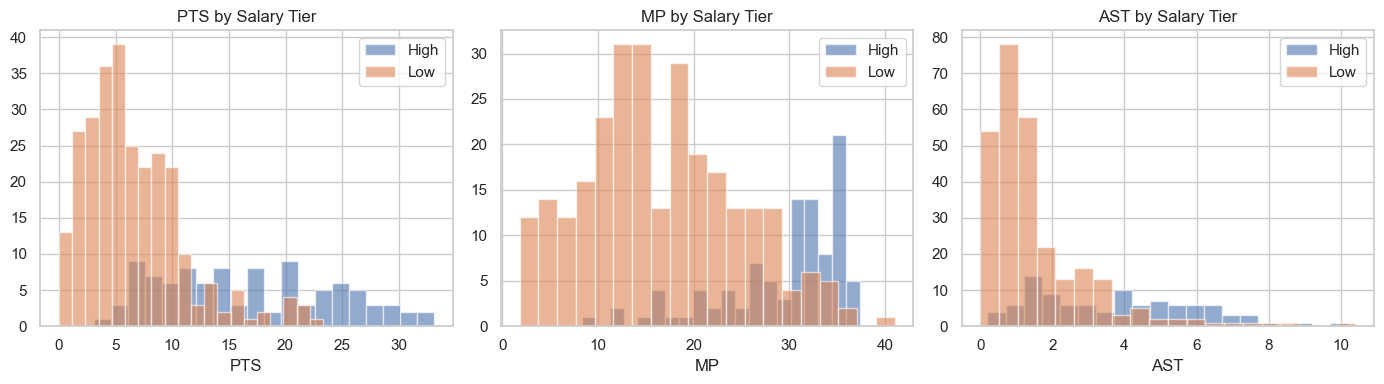

In [6]:
# Quick EDA on training set 
# Reconstruct df for plotting purposes
eda_df = X_trainval.copy()
eda_df['SalaryTier'] = y_trainval.values

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, ['PTS', 'MP', 'AST']):
    for tier, grp in eda_df.groupby('SalaryTier'):
        ax.hist(grp[col], bins=20, alpha=0.6, label=tier)
    ax.set_title(f'{col} by Salary Tier')
    ax.set_xlabel(col)
    ax.legend()
plt.tight_layout()
plt.show()

# Methods: Training and Validation

we evaluated five classification model variations using the training/validation set as stated on the Project S description. The models tested were:
1. Dummy Classifier 
2. Decision Tree Classifier with depth of 3  
3. Decision Tree Classifier with depth of 10  
4. Random Forest Classifier with 100 trees and depth of 5  
5. Random Forest Classifier with 200 trees and no depth limit  

We used **5-fold stratified cross-validation** with a random seed. 42 bc its the hitchikers meme 

For each model, we built a pipeline containing `StandardScaler()` for all five models.

We evaluated using cross-validation accuracy. and cross-validation ROC-AUC when available. The Dummy baseline was intitially just to give us a baseline, but performed decently and gave us a good idea of how much real models would improve accuracy this was exceptionally aparent using ROC-AUC.

After computing the validation results, we summarized the mean accuracy and standard deviation for each model and displayed the results in a bar chart. We also trained a depth-3 decision tree on the full training/validation set and visualized it I will explain that below.

In [7]:
# Define 5 model variations
models_to_try = {
    '1_Dummy (Baseline)':                dummy.DummyClassifier(strategy='most_frequent'),
    '2_Decision Tree (depth=3)':         tree.DecisionTreeClassifier(max_depth=3, random_state=42),
    '3_Decision Tree (depth=10)':        tree.DecisionTreeClassifier(max_depth=10, random_state=42),
    '4_Random Forest (100t, depth=5)':   RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42),
    '5_Random Forest (200t, no limit)':  RandomForestClassifier(n_estimators=200, max_depth=None, random_state=42),
}

cv = skms.StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = []
for name, model in models_to_try.items():
    pipe = pipeline.Pipeline([
        ('scaler', skpre.StandardScaler()),
        ('clf', model)
    ])
    acc_scores = skms.cross_val_score(pipe, X_trainval, y_trainval, cv=cv, scoring='accuracy')
    # Note: DummyClassifier doesn't support predict_proba with most_frequent for roc_auc → skip for baseline
    try:
        auc_scores = skms.cross_val_score(pipe, X_trainval, y_trainval, cv=cv,
                                          scoring='roc_auc')
        mean_auc = auc_scores.mean()
    except Exception:
        mean_auc = np.nan

    results.append({
        'Model': name,
        'CV Accuracy (mean)': acc_scores.mean().round(4),
        'CV Accuracy (std)':  acc_scores.std().round(4),
        'CV ROC-AUC (mean)':  round(mean_auc, 4) if not np.isnan(mean_auc) else 'N/A'
    })
    print(f'{name}: Acc={acc_scores.mean():.4f} ± {acc_scores.std():.4f}')

results_df = pd.DataFrame(results)
display(results_df)

1_Dummy (Baseline): Acc=0.7346 ± 0.0045
2_Decision Tree (depth=3): Acc=0.8792 ± 0.0313
3_Decision Tree (depth=10): Acc=0.8551 ± 0.0316
4_Random Forest (100t, depth=5): Acc=0.8711 ± 0.0331
5_Random Forest (200t, no limit): Acc=0.8712 ± 0.0307


,Model,CV Accuracy (mean),CV Accuracy (std),CV ROC-AUC (mean)
0,1_Dummy (Baseline),0.7346,0.0045,0.5000
1,2_Decision Tree (depth=3),0.8792,0.0313,0.8553
2,3_Decision Tree (depth=10),0.8551,0.0316,0.8105
3,"4_Random Forest (100t, depth=5)",0.8711,0.0331,0.9274
4,"5_Random Forest (200t, no limit)",0.8712,0.0307,0.9281


### Bar chart
This chart is rather simple it just visulizes the accuracy results, we used ai to build these as they just looked better than our attempts and do a great job at visualizing the data 

### Decision Tree 

The depth-3 decision tree provides a view of how the model separates players into High and Low salary tiers.

The first and most important split is based on minutes played per game (MP). playing time is the strongest single predictor in the tree for salary level. Players with lower minutes per game are more likely to fall into the Low salary tier, while players with higher minutes per game are more likely to be classified as High salary.

After the initial split, the tree uses other features:
- **TRB** (total rebounds per game)
- **3PA** (three-point attempts per game)
- **Age**
- **2PA** (two-point attempts per game)
- **ORB** (offensive rebounds per game)

These later splits help refine the classification. For example, among players with higher minutes played, the tree checks age and scoring-related statistics to further separate likely high-salary players from low-salary players.

Because the tree is limited to depth 3, it remains easy to interpret while still capturing the anaylysis made by the model. this gives us an easy to explain model that performs well, a human could read this chart and get a similar accuracy level by going down the tree.

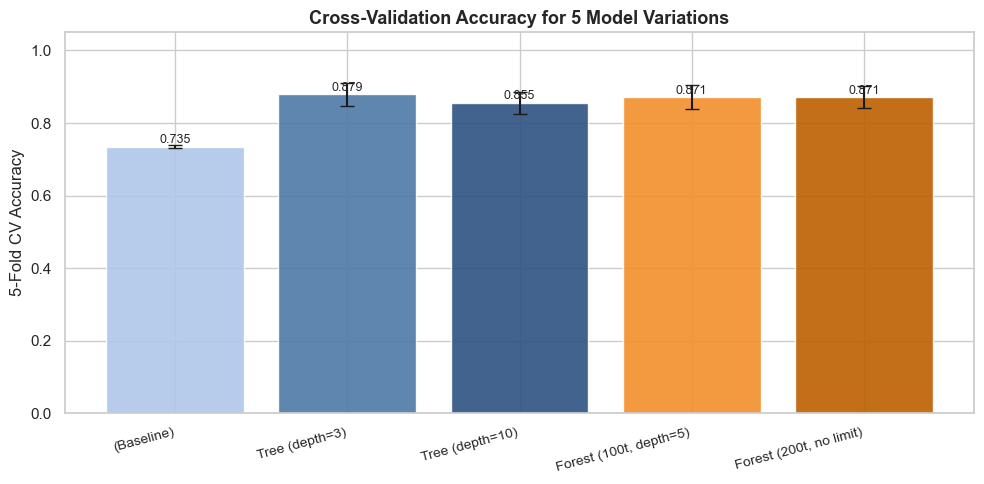

In [ ]:
# Visualise cross-validation accuracy 
fig, ax = plt.subplots(figsize=(10, 5))

model_names  = results_df['Model']
mean_acc     = results_df['CV Accuracy (mean)'].astype(float)
std_acc      = results_df['CV Accuracy (std)'].astype(float)
colors = ['#aec7e8', '#4e79a7', '#2c5282', '#f28e2b', '#bd5e00'] #Air Force Blue, Navy, Dark Blue, Orange, Dark Orange AI generated color palette

bars = ax.bar(range(len(model_names)), mean_acc, yerr=std_acc,
              capsize=5, color=colors, edgecolor='white', alpha=0.9)
ax.set_xticks(range(len(model_names)))
ax.set_xticklabels([n.split(' ', 1)[1] for n in model_names], rotation=15, ha='right', fontsize=10)
ax.set_ylabel('5-Fold CV Accuracy')
ax.set_title('Cross-Validation Accuracy for 5 Model Variations', fontsize=13, fontweight='bold')
ax.set_ylim(0, 1.05)
for bar, v in zip(bars, mean_acc):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{v:.3f}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

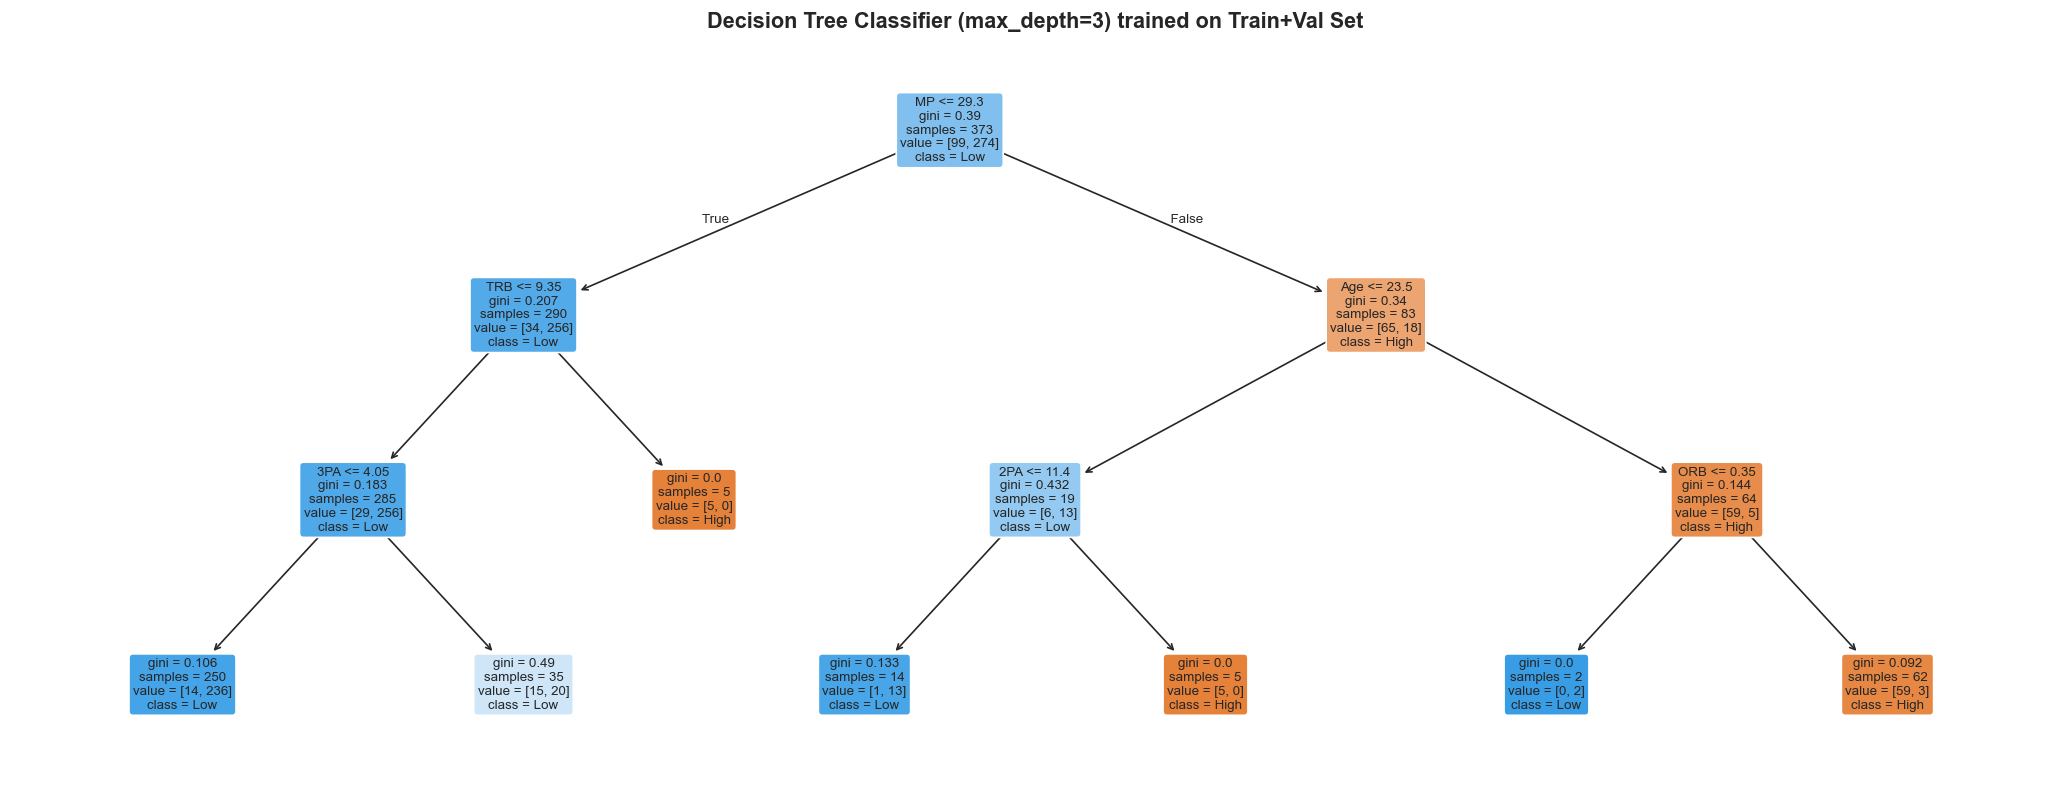

In [9]:
# Visualise one of the decision trees (depth=3)
# Train just the DTC on full train+val set for visualization
dtc_viz = tree.DecisionTreeClassifier(max_depth=3, random_state=42)
dtc_viz.fit(X_trainval, y_trainval)

plt.figure(figsize=(22, 8), dpi=120)
tree.plot_tree(dtc_viz,
               filled=True,
               feature_names=X_trainval.columns.tolist(),
               class_names=['High', 'Low'],
               rounded=True,
               fontsize=8)
plt.title('Decision Tree Classifier (max_depth=3) trained on Train+Val Set', fontsize=13, fontweight='bold')
plt.show()

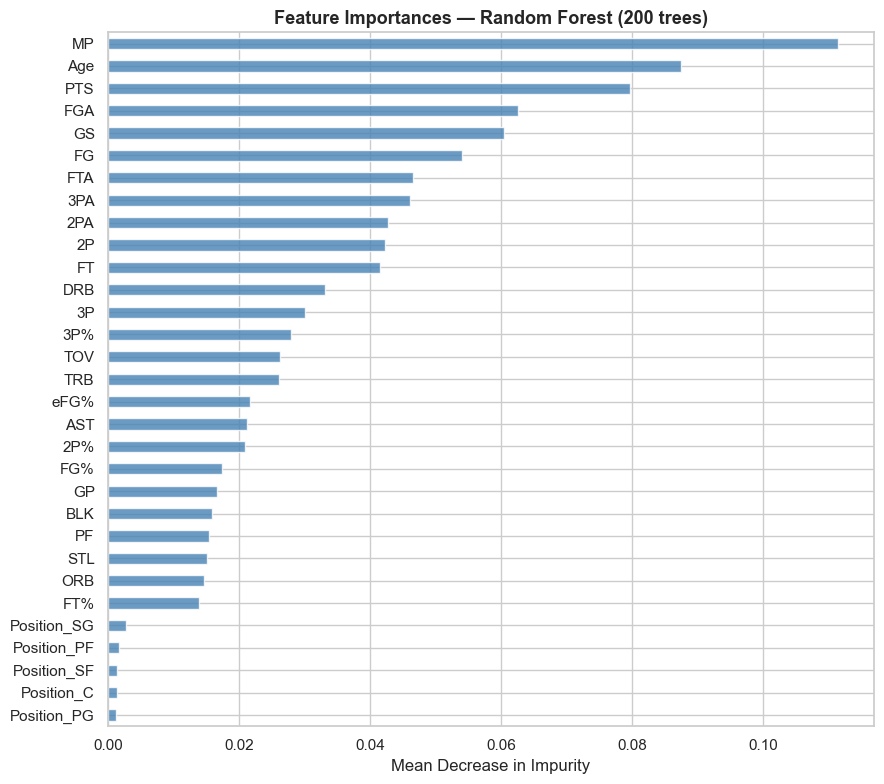

In [10]:
# Feature importances from the best Random Forest
# Train best RF on full train+val for importance plot
best_rf_for_plot = RandomForestClassifier(n_estimators=200, max_depth=None, random_state=42)
best_rf_for_plot.fit(X_trainval, y_trainval)

importances = pd.Series(best_rf_for_plot.feature_importances_, index=X_trainval.columns)
importances_sorted = importances.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 8))
importances_sorted.plot(kind='barh', ax=ax, color='steelblue', alpha=0.8)
ax.set_title('Feature Importances — Random Forest (200 trees)', fontsize=13, fontweight='bold')
ax.set_xlabel('Mean Decrease in Impurity')
plt.tight_layout()
plt.show()

## Final Model Evaluation

After comparing model variations during cross-validation, we selected a Random Forest Classifier with 200 trees and no maximum depth limit as the final model. We retrained using the full training/validation set so that it could learn from all available non-test data before final evaluation.

These results help evaluate not only overall correctness, but also how well the model performs for both the **High** and **Low** salary groups individually.

In [11]:
# Final model: retrain on full train+val, evaluate on test 
final_model = pipeline.Pipeline([
    ('scaler', skpre.StandardScaler()),
    ('clf', RandomForestClassifier(n_estimators=200, max_depth=None, random_state=42))
])
final_model.fit(X_trainval, y_trainval)

y_pred  = final_model.predict(X_test)
y_proba = final_model.predict_proba(X_test)[:, 1]  # probability of 'Low' class

test_acc = metrics.accuracy_score(y_test, y_pred)
print(f'Test Accuracy:  {test_acc:.4f}')
print(f'\nClassification Report:')
print(metrics.classification_report(y_test, y_pred))

Test Accuracy:  0.8617

Classification Report:
              precision    recall  f1-score   support

        High       0.88      0.56      0.68        25
         Low       0.86      0.97      0.91        69

    accuracy                           0.86        94
   macro avg       0.87      0.77      0.80        94
weighted avg       0.86      0.86      0.85        94



## Confusion Matrix

In this project, the confusion matrix is especially useful because it shows whether the model is better at identifying High salary players or Low salary players, rather than only reporting a single overall accuracy value.
Predicting high salary players doesnt quite meet the accuracy we were hoping for but with a high threshold for salary, we still get good results in the future we may try retraining with diffrent thresholds.

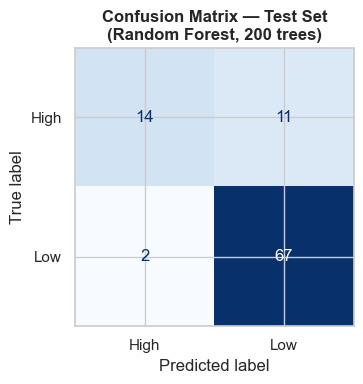

In [12]:
# Confusion matrix 
cm = metrics.confusion_matrix(y_test, y_pred, labels=['High', 'Low'])
disp = metrics.ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['High', 'Low'])

fig, ax = plt.subplots(figsize=(5, 4))
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix — Test Set\n(Random Forest, 200 trees)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

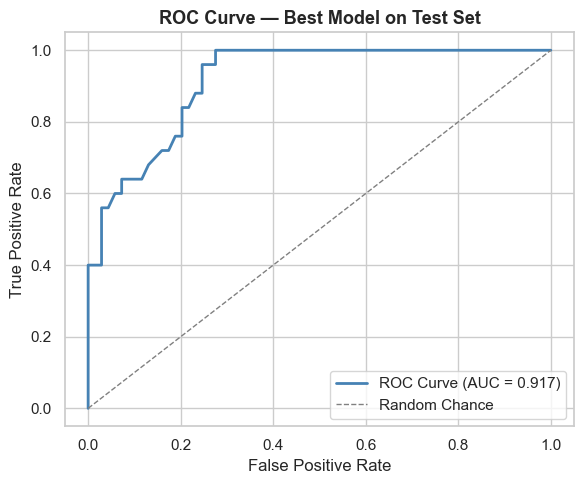

ROC-AUC on test set: 0.9165


In [13]:
# ROC Curve
# Encode target as 0/1 for ROC (High=1, Low=0)
label_enc = skpre.LabelEncoder()
y_test_bin = label_enc.fit_transform(y_test)  # High→0, Low→1 (alphabetical)
# We want High=1, so invert if needed
if label_enc.classes_[0] == 'High':
    # predict_proba column 0 = 'High' → use column 0 as score for High
    y_score_high = final_model.predict_proba(X_test)[:, 0]
    y_test_bin_high = (y_test == 'High').astype(int)
else:
    y_score_high = final_model.predict_proba(X_test)[:, 1]
    y_test_bin_high = (y_test == 'High').astype(int)

fpr, tpr, _ = metrics.roc_curve(y_test_bin_high, y_score_high)
roc_auc = metrics.auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, color='steelblue', lw=2, label=f'ROC Curve (AUC = {roc_auc:.3f})')
ax.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1, label='Random Chance')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve — Best Model on Test Set', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

print(f'ROC-AUC on test set: {roc_auc:.4f}')